In [22]:

# 02_evaluation.ipynb の最初のセル
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib


# データ読み込み
with open('../data/worker_data.pkl', 'rb') as f:
    data = pickle.load(f)


print("データ読み込み完了")
print(f"CS数: {len(data['cs_config']['csids'])}")
print(f"時系列データ: {data['time_series_kw'].shape}")

# ここから評価処理開始...

データ読み込み完了
CS数: 8
時系列データ: (1440, 8)


In [23]:

# 2つ目のセル：データ確認
timeseries_kw = data['time_series_kw']
timeseries_waiting_line = data['waiting_line']
vehicle_trip = data['vehicle_trip']
cs_config = data['cs_config']
charging_loss = data['charging_loss']
actual_csids = timeseries_kw.columns.tolist()
candidate_csids = cs_config['csids']

print("=== データ概要 ===")
print(f"時系列データ: {timeseries_kw.shape}")
print(f"期間: {timeseries_kw.index.min()} - {timeseries_kw.index.max()}")
print(f"CS数: {len(cs_config['csids'])}")
print(f"EV車両トリップ数: {len(vehicle_trip)}")
print(f"充電損失: {charging_loss.shape}")
print(f"設置CS: {actual_csids}")
print(f"候補地数: {len(candidate_csids)}")

cs_config_df = pd.DataFrame(cs_config)
print("=== CS設定 ===")
print(cs_config_df.head())
# 保存
cs_config_df.to_csv('../data/cs_config.csv', index=False)

=== データ概要 ===
時系列データ: (1440, 8)
期間: 60 - 86400
CS数: 8
EV車両トリップ数: 19771
充電損失: (13, 6)
設置CS: ['900000', '900002', '900004', '900006', '900008', '900010', '900012', '900014']
候補地数: 8
=== CS設定 ===
    csids  ports  cap_kw  total_ports
0  900000      2      90           16
1  900002      2      90           16
2  900004      2      90           16
3  900006      2      90           16
4  900008      2      90           16


In [24]:

# 4つ目のセル：充電ステーションの設定確認
# CSの出力とポート数
capacity_list = cs_config['cap_kw']
ports_list = cs_config['ports']
# 0ならNaNに
capacity_list = [np.nan if cap == 0 else cap for cap in capacity_list]
ports_list = [np.nan if port == 0 else port for port in ports_list]
#
ports_array = np.array(ports_list)
capacity_array = np.array(capacity_list)

# 評価指標：利用率，待ち行列
# 各CSの利用率を計算　利用率＝ 実際の充電量 / 最大充電容量
max_capacity = ports_array * capacity_array
utilization = timeseries_kw / max_capacity

# 後のために形状を調整
max_capacity.shape = (-1,1)  

utilization_mean = utilization.mean(axis=0)
print(f"各CSの平均利用率:\n{utilization_mean}")
print(f"最大容量：{max_capacity}")

# 各CSの待ち行列
waiting_line_mean = timeseries_waiting_line.mean(axis=0)


各CSの平均利用率:
900000    0.442708
900002    0.174653
900004    0.067014
900006    0.075000
900008    0.000000
900010    0.050000
900012    0.000000
900014    0.067361
dtype: float64
最大容量：[[180]
 [180]
 [180]
 [180]
 [180]
 [180]
 [180]
 [180]]


In [25]:
# 評価指標：待ち時間,走行距離
# 待ち時間＝ 充電開始時間 - 待機列に入った時間
charging_trip = vehicle_trip[vehicle_trip['startChargingTime'] != 0]
# EndTimeがNaNの行を特定
nan_endtime = charging_trip['EndTime'].isna()
print(f"EndTimeがNaNの件数: {nan_endtime.sum()}")

# 完了した充電のみを抽出
completed_charging = charging_trip[~nan_endtime].copy()
print(f"完了した充電件数: {len(completed_charging)}")

# 以降の分析は完了した充電データのみ使用
charging_trip = completed_charging

waiting_times = charging_trip['startChargingTime'].values - charging_trip['WaitingEntryTime'].values

# どこで充電待ちが発生しているかを確認するために，0秒以上の待ち時間があるものを抽出
is_waiting = waiting_times > 0
non_zero_wait = charging_trip[is_waiting]

non_zero_waiting_times = waiting_times[is_waiting]

waiting_cs = non_zero_wait['CSID'].value_counts()


print(f"充電待ち時間の平均: {np.mean(waiting_times):.2f} 秒")
print(f"充電待ち時間の最大: {np.max(waiting_times):.2f} 秒")
print(f"充電待ちが発生しているCS:{waiting_cs.index.tolist()}")


EndTimeがNaNの件数: 3
完了した充電件数: 103
充電待ち時間の平均: 11.16 秒
充電待ち時間の最大: 655.50 秒
充電待ちが発生しているCS:[900000.0, 900002.0]


In [26]:
# 評価指標：迂回距離＝ 充電を行った車両の走行距離 - 充電を行わなかった車両の走行距離
# OD情報をもとに充電によってどれだけ走行距離が変化したかを確認
# ここでは，到着地点が同じであれば同じ経路を通ったと仮定
# vehicle_tripのgoalIDが同一のものを取得
# 充電を行った車両とそうでない車の走行距離を比較
no_charging_trip = vehicle_trip[vehicle_trip['startChargingTime'] == 0]

od_length = no_charging_trip.groupby('goalID')['tripLength'].mean().reset_index()
charging_od_length = charging_trip.groupby('goalID')['tripLength'].mean().reset_index()

#print(f"ODごとの走行距離:\n{od_length}")
#print(f"充電を行ったODごとの走行距離:\n{charging_od_length}")

# 充電を行ったODとそうでないODの走行距離を比較
od_comparison = pd.merge(od_length, charging_od_length, on='goalID', suffixes=('_no_charging', '_charging'))
od_comparison['distance_difference'] = od_comparison['tripLength_charging'] - od_comparison['tripLength_no_charging']
print(f"ODごとの迂回距離:\n{od_comparison[['goalID', 'distance_difference']]}")


ODごとの迂回距離:
   goalID  distance_difference
0     4.0            97.151972
1   169.0           911.637479
2   525.0            76.417932
3  1031.0           108.921105
4  1086.0            83.832467
5  1087.0          2511.534182
6  1123.0           110.244408
7  1437.0           555.565633


In [27]:
# ✅ 実設置CS別待ち時間指標の計算
print("=== 実設置CS別待ち時間指標の計算 ===")

# 実設置CS別待ち時間統計を作成
cs_waiting_stats = {}

if len(non_zero_wait) > 0:
    # 実設置CSIDごとの待ち時間統計
    for csid in actual_csids:
        cs_trips = non_zero_wait[non_zero_wait['CSID'] == csid]
        
        if len(cs_trips) > 0:
            cs_waiting_times = (cs_trips['startChargingTime'].values - 
                              cs_trips['WaitingEntryTime'].values)
            
            # そのCSでの全充電回数（待ちなしも含む）
            total_cs_trips = charging_trip[charging_trip['CSID'] == csid]
            
            cs_waiting_stats[csid] = {
                '待ち時間平均': np.mean(cs_waiting_times),
                '待ち時間最大': np.max(cs_waiting_times),
                '待ち発生回数': len(cs_waiting_times),
                '総充電回数': len(total_cs_trips),
                '待ち発生率': len(cs_waiting_times) / len(total_cs_trips) if len(total_cs_trips) > 0 else 0
            }
        else:
            # 待ちはないが充電はある場合
            total_cs_trips = charging_trip[charging_trip['CSID'] == csid]
            cs_waiting_stats[csid] = {
                '待ち時間平均': 0,
                '待ち時間最大': 0,
                '待ち発生回数': 0,
                '総充電回数': len(total_cs_trips),
                '待ち発生率': 0
            }

print(f"実設置CS別待ち時間統計: {len(cs_waiting_stats)} 箇所")

# ✅ 実設置CS別迂回距離指標の計算
print("=== 実設置CS別迂回距離指標の計算 ===")

cs_detour_stats = {}

for csid in actual_csids:
    # そのCSで充電した車両のデータ
    cs_charging_trips = charging_trip[charging_trip['CSID'].astype(int) == int(csid) // 100]
    
    if len(cs_charging_trips) > 0:
        # goalIDごとの迂回距離を計算
        cs_detours = []
        
        for _, trip in cs_charging_trips.iterrows():
            goal_id = trip['goalID']
            trip_length = trip['tripLength']
            
            # 同じgoalIDの非充電車両の平均距離
            same_goal_no_charging = no_charging_trip[no_charging_trip['goalID'] == goal_id]
            
            if len(same_goal_no_charging) > 0:
                baseline_length = same_goal_no_charging['tripLength'].mean()
                detour = trip_length - baseline_length
                cs_detours.append(detour)
        
        if cs_detours:
            cs_detour_stats[csid] = {
                '迂回距離平均': np.mean(cs_detours),
                '迂回距離最大': np.max(cs_detours),
                '迂回距離最小': np.min(cs_detours),
                '迂回車両数': len(cs_detours),
                '総充電車両数': len(cs_charging_trips)
            }
        else:
            cs_detour_stats[csid] = {
                '迂回距離平均': 0,
                '迂回距離最大': 0,
                '迂回距離最小': 0,
                '迂回車両数': 0,
                '総充電車両数': len(cs_charging_trips)
            }
    else:
        cs_detour_stats[csid] = {
            '迂回距離平均': 0,
            '迂回距離最大': 0,
            '迂回距離最小': 0,
            '迂回車両数': 0,
            '総充電車両数': 0
        }

print(cs_detour_stats)

=== 実設置CS別待ち時間指標の計算 ===
実設置CS別待ち時間統計: 8 箇所
=== 実設置CS別迂回距離指標の計算 ===
{'900000': {'迂回距離平均': 0, '迂回距離最大': 0, '迂回距離最小': 0, '迂回車両数': 0, '総充電車両数': 0}, '900002': {'迂回距離平均': 0, '迂回距離最大': 0, '迂回距離最小': 0, '迂回車両数': 0, '総充電車両数': 0}, '900004': {'迂回距離平均': 0, '迂回距離最大': 0, '迂回距離最小': 0, '迂回車両数': 0, '総充電車両数': 0}, '900006': {'迂回距離平均': 0, '迂回距離最大': 0, '迂回距離最小': 0, '迂回車両数': 0, '総充電車両数': 0}, '900008': {'迂回距離平均': 0, '迂回距離最大': 0, '迂回距離最小': 0, '迂回車両数': 0, '総充電車両数': 0}, '900010': {'迂回距離平均': 0, '迂回距離最大': 0, '迂回距離最小': 0, '迂回車両数': 0, '総充電車両数': 0}, '900012': {'迂回距離平均': 0, '迂回距離最大': 0, '迂回距離最小': 0, '迂回車両数': 0, '総充電車両数': 0}, '900014': {'迂回距離平均': 0, '迂回距離最大': 0, '迂回距離最小': 0, '迂回車両数': 0, '総充電車両数': 0}}


In [28]:
# 実設置CS別待ち時間統計を作成
cs_waiting_stats = {}
for csid in actual_csids:
    # そのCSで充電した車両のデータ
    total_cs_trips = charging_trip[charging_trip['CSID'].astype(int)  == int(csid) // 100]
    if len(total_cs_trips) > 0:

        # 充電待ち時間
        cs_waiting_times = (total_cs_trips['startChargingTime'].values - 
                            total_cs_trips['WaitingEntryTime'].values)
        
        # そのCSで充電待ちが発生している車両のデータ。0より大きい待ち時間のみを抽出
        cs_waiting_times_non_zero = cs_waiting_times[cs_waiting_times > 0]

        cs_waiting_stats[csid] = {
            '待ち時間平均': np.mean(cs_waiting_times),
            '待ち時間最大': np.max(cs_waiting_times),
            '待ち発生回数': len(cs_waiting_times_non_zero),
            '総充電回数': len(total_cs_trips),
            '待ち発生率': len(cs_waiting_times_non_zero) / len(total_cs_trips) if len(total_cs_trips) > 0 else 0
        }
    else:
        cs_waiting_stats[csid] = {
            '待ち時間平均': 0,
            '待ち時間最大': 0,
            '待ち発生回数': 0,
            '総充電回数': 0,
            '待ち発生率': 0
        }

In [67]:
csids = cs_config.get('csids', [])
ports = cs_config.get('ports', [])
capacity_kw = cs_config.get('cap_kw', [])
for i in range(len(csids)):
    print(f"CSID: {csids[i]}, ポート数: {ports[i]}, 容量: {capacity_kw[i]} kW")

CSID: 900000, ポート数: 2, 容量: 90 kW
CSID: 900002, ポート数: 2, 容量: 90 kW
CSID: 900004, ポート数: 2, 容量: 90 kW
CSID: 900006, ポート数: 2, 容量: 90 kW
CSID: 900008, ポート数: 2, 容量: 90 kW
CSID: 900010, ポート数: 2, 容量: 90 kW
CSID: 900012, ポート数: 2, 容量: 90 kW
CSID: 900014, ポート数: 2, 容量: 90 kW


In [ ]:
# ✅ 修正版：CS別充足率の計算
print("=== CS別充足率の計算 ===")

NEED_SOC = 0.8
BATTERY_CAPACITY = 60  # 車両のバッテリー容量 (kWh)

# 実際の充電量（CS別）
actual_charging_kwh = timeseries_kw.sum(axis=0) / 60  # kWからkWhに変換

# CS別充足率統計を作成
cs_satisfaction_stats = {}

for i, csid in enumerate(actual_csids):
        # そのCSでの充電損失データを取得
        cs_chr_loss = charging_loss[charging_loss['CSID'].astype(int)  == int(csid) // 100]
        
        if not cs_chr_loss.empty:
            # 充電損失によるkWh計算
            chr_loss_soc = cs_chr_loss['SOC'].values
            cs_chr_loss_kwh = np.sum(BATTERY_CAPACITY * (NEED_SOC - chr_loss_soc))
            
            # そのCSの実際の充電量
            cs_actual_charging_kwh = actual_charging_kwh.iloc[i]
            
            # 潜在的な需要（実際の充電量 + 充電損失）
            cs_potential_demand_kwh = cs_actual_charging_kwh + cs_chr_loss_kwh
            
            # 充足率の計算
            if cs_potential_demand_kwh > 0:
                cs_satisfaction_rate = (cs_actual_charging_kwh / cs_potential_demand_kwh) * 100
            else:
                cs_satisfaction_rate = 0
                
            cs_satisfaction_stats[csid] = {
                "実際の充電量 (kWh)": float(cs_actual_charging_kwh),
                "充電損失量 (kWh)": float(cs_chr_loss_kwh),
                "潜在的需要 (kWh)": float(cs_potential_demand_kwh),
                "充足率 (%)": float(cs_satisfaction_rate),
                "充電損失件数": len(cs_chr_loss)
            }
        else:
            # 充電損失がない場合
            cs_actual_charging_kwh = actual_charging_kwh.iloc[i]
            cs_satisfaction_stats[csid] = {
                "実際の充電量 (kWh)": float(cs_actual_charging_kwh),
                "充電損失量 (kWh)": 0.0,
                "潜在的需要 (kWh)": float(cs_actual_charging_kwh),
                "充足率 (%)": 100.0,
                "充電損失件数": 0
            }
            

print(f"CS別充足率統計: {len(cs_satisfaction_stats)} 箇所")

# 結果の表示
print("\nCS別充足率統計（上位5箇所）:")
for i, (csid, stats) in enumerate(cs_satisfaction_stats.items()):
    if i < 5:
        print(f"CS {csid}:")
        print(f"  実際の充電量: {stats['実際の充電量 (kWh)']:.1f} kWh")
        print(f"  充電損失量: {stats['充電損失量 (kWh)']:.1f} kWh")
        print(f"  潜在的需要: {stats['潜在的需要 (kWh)']:.1f} kWh")
        print(f"  充足率: {stats['充足率 (%)']:.1f}%")
        print(f"  充電損失件数: {stats['充電損失件数']} 件")
        print()

バイナリ変数を口数，充電出力で決定し，
Gurobiで出てくる出力を一旦ematesで回してみる。
手計算


In [49]:
demand_matrix = timeseries_kw.values


In [50]:
# ✅ 実用的アプローチ：CS別データでの相関分析
print("\n=== CS別データによる相関分析 ===")

# CS別の指標データを作成（実設置CSのみ）
cs_data_list = []

for i, csid in enumerate(actual_csids):
    # 各CSの指標
    cs_metrics = {
        'CSID': csid,
        '利用率': utilization_mean.iloc[i],
        '設置容量': max_capacity[i] if i < len(max_capacity) else 0,
        '初期コスト': initial_costs_filtered[i] if i < len(initial_costs_filtered) else 0,
        '充足率': cs_satisfaction_stats[csid]['充足率 (%)'],
        '充電損失量': cs_satisfaction_stats[csid]['充電損失量 (kWh)'],
        '待ち発生率': cs_waiting_stats[csid]['待ち発生率'],
        '待ち時間平均': cs_waiting_stats[csid]['待ち時間平均'],
        '迂回距離平均': cs_detour_stats[csid]['迂回距離平均'] if csid in cs_detour_stats else 0
    }
    
    cs_data_list.append(cs_metrics)

# DataFrame作成
cs_correlation_df = pd.DataFrame(cs_data_list)
if 'CSID' in cs_correlation_df.columns:
    cs_correlation_df.index = cs_correlation_df['CSID']
    cs_correlation_df = cs_correlation_df.drop(columns=['CSID'])
print(f"実設置CS別データ: {cs_correlation_df.shape}")
print(cs_correlation_df.head())

cs_correlation_matrix = cs_correlation_df.corr()

print(f"\nCS別相関行列:")
print(cs_correlation_matrix.round(3))

# 保存
import pickle

with open('../data/cs_metrics.pkl', 'wb') as f:
    pickle.dump(cs_correlation_df, f)

print("データ保存完了")


=== CS別データによる相関分析 ===


NameError: name 'filtered_max_capacity' is not defined

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]),
 [Text(0, 0.5, '利用率'),
  Text(0, 1.5, '設置容量'),
  Text(0, 2.5, '初期コスト'),
  Text(0, 3.5, '充足率'),
  Text(0, 4.5, '充電損失量'),
  Text(0, 5.5, '待ち発生率'),
  Text(0, 6.5, '待ち時間平均'),
  Text(0, 7.5, '迂回距離平均')])

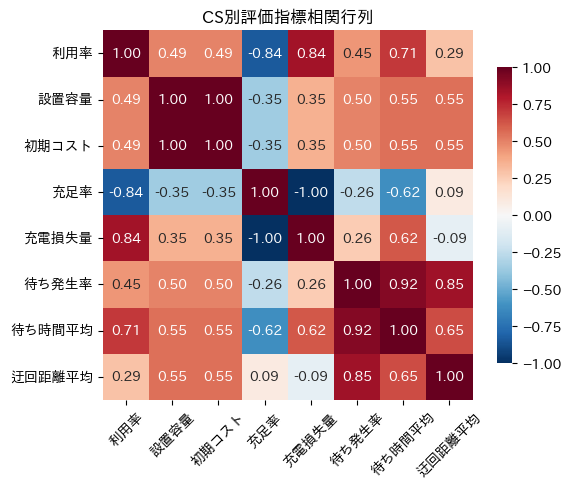

In [ ]:
import seaborn as sns
sns.heatmap(cs_correlation_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('CS別評価指標相関行列')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

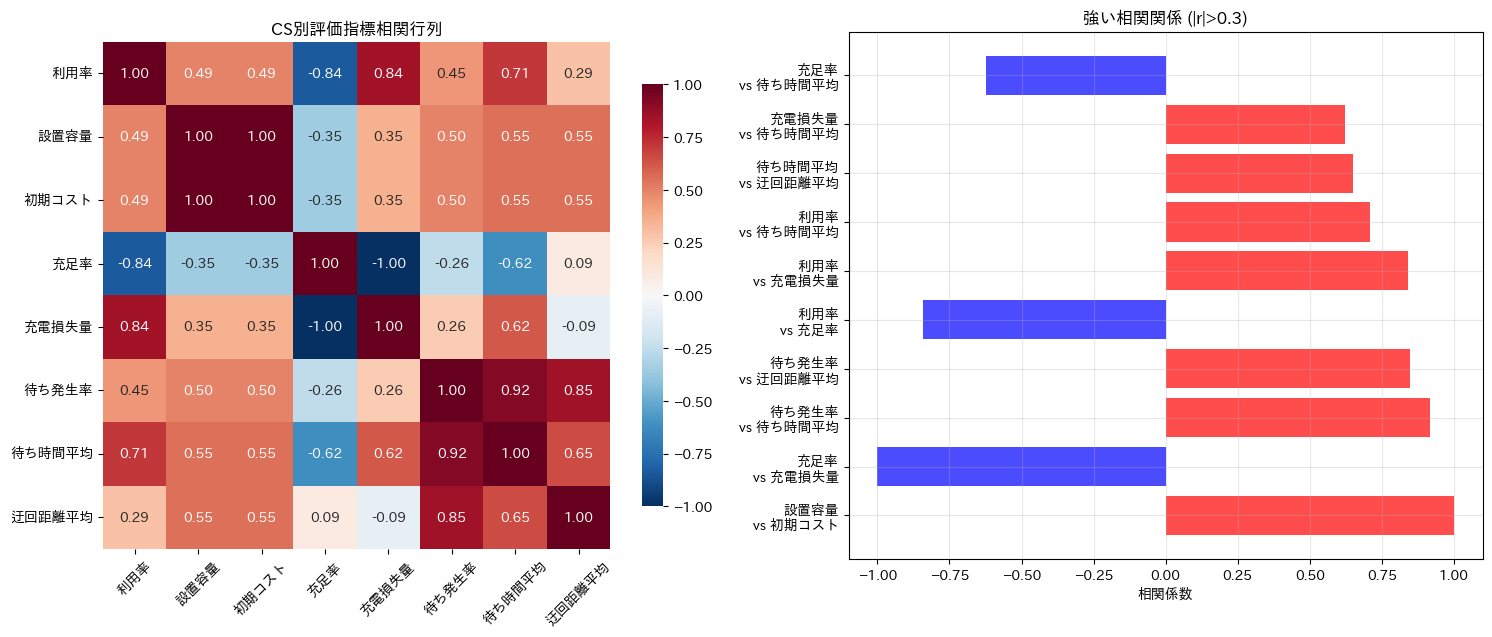

利用率に対する決定係数: 0.893
利用率に対する回帰係数:
設置容量: 0.005
初期コスト: 0.009
充足率: 0.205
充電損失量: 0.213
待ち発生率: 0.052
待ち時間平均: 0.038
迂回距離平均: 0.479


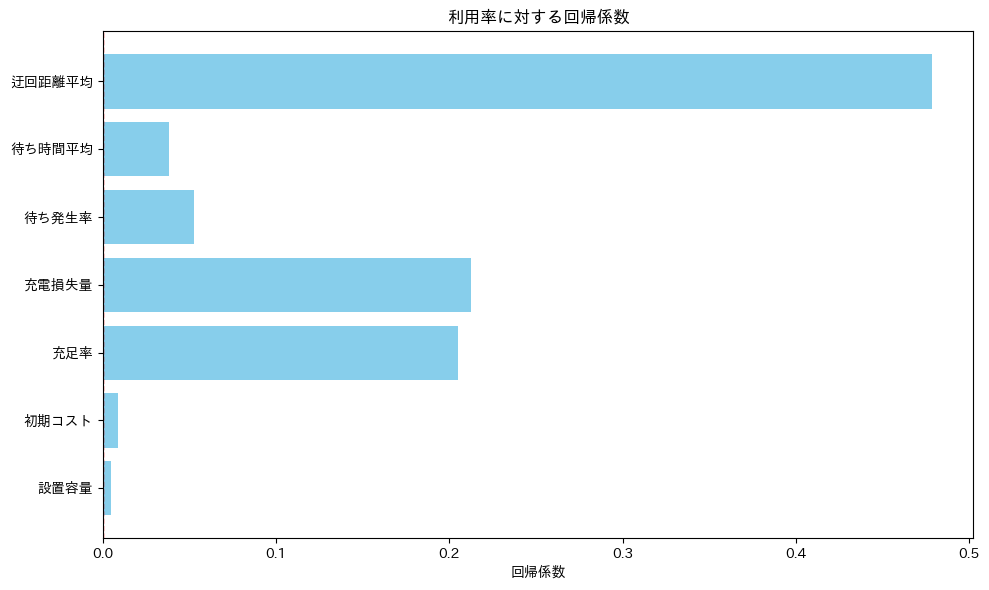

In [ ]:
# ✅ 相関行列の可視化
plt.figure(figsize=(15, 12))

# サブプロット1: CS別相関ヒートマップ
plt.subplot(2, 2, 1)
import seaborn as sns
sns.heatmap(cs_correlation_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('CS別評価指標相関行列')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# サブプロット2: 強い相関の可視化
plt.subplot(2, 2, 2)
# 相関の絶対値が高い組み合わせを抽出
strong_correlations = []
for i in range(len(cs_correlation_matrix.columns)):
    for j in range(i+1, len(cs_correlation_matrix.columns)):
        col1 = cs_correlation_matrix.columns[i]
        col2 = cs_correlation_matrix.columns[j]
        corr_val = cs_correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.3:  # 0.3以上の相関
            strong_correlations.append((f"{col1}-{col2}", corr_val))

# 相関値でソート
strong_correlations.sort(key=lambda x: abs(x[1]), reverse=True)

if strong_correlations:
    pairs, values = zip(*strong_correlations[:10])  # 上位10個
    colors = ['blue' if v < 0 else 'red' for v in values]
    plt.barh(range(len(pairs)), values, color=colors, alpha=0.7)
    plt.yticks(range(len(pairs)), [p.replace('-', '\nvs ') for p in pairs])
    plt.xlabel('相関係数')
    plt.title('強い相関関係 (|r|>0.3)')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 利用率に対する決定係数の計算
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
# 利用率と他の指標の関係を線形回帰で分析
X = cs_correlation_df.drop(columns=['利用率'])
y = cs_correlation_df['利用率']
model = RandomForestRegressor()
model.fit(X, y)
# 決定係数
r_squared = model.score(X, y)
print(f"利用率に対する決定係数: {r_squared:.3f}")
# 利用率に対する回帰係数
coefficients = model.feature_importances_
print("利用率に対する回帰係数:")
for feature, coef in zip(X.columns, coefficients):
    print(f"{feature}: {coef:.3f}")
# 可視化
plt.figure(figsize=(10, 6))
plt.barh(X.columns, coefficients, color='skyblue')
plt.xlabel('回帰係数')
plt.title('利用率に対する回帰係数')
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()

# 保存

指標間の関係性を確認するために，相関行列を作成。
主に強い相関がみられ，かつ意味のありそうな相関は
・利用率VS待ち時間
・利用率VS充足率（＝充電量/（充電量＋充電損失量））


In [ ]:
# 決定係数の計算
from sklearn.linear_model import LinearRegression
def calculate_r_squared(X, y):
    model = LinearRegression()
    model.fit(X, y)
    r_squared = model.score(X, y)
    return r_squared
# 各指標の決定係数を計算
r_squared_values = {}
for column in y.columns:
    r_squared = calculate_r_squared(X, y[column])
    r_squared_values[column] = r_squared
    


決定木の特徴量重要度:
     特徴量  重要度
0    利用率  0.0
1   設置容量  0.0
2  初期コスト  0.0
3  充電損失量  0.0


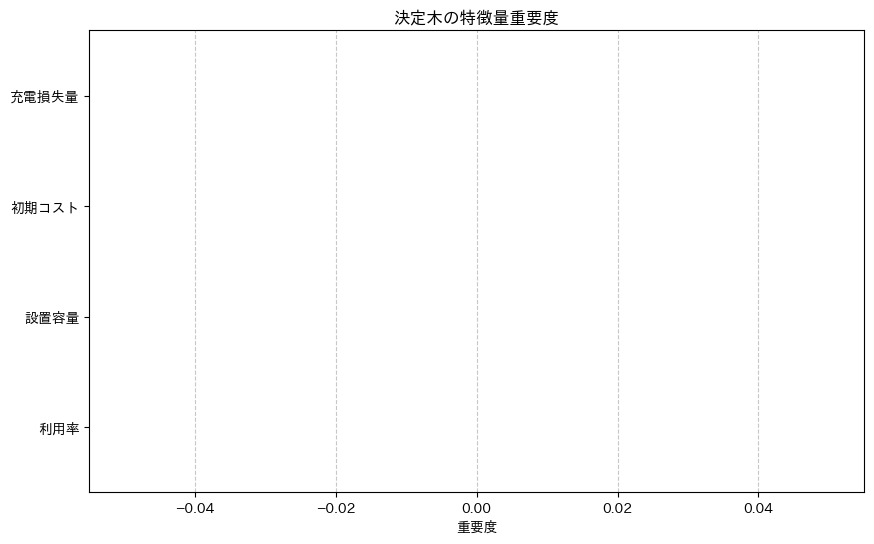

In [ ]:
# 決定木の可視化
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import train_test_split
# 特徴量とターゲットの設定
X = cs_correlation_df.drop(columns=['充足率', '待ち発生率', '待ち時間平均', '迂回距離平均'])
y = cs_correlation_df['充足率']
# データの分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 決定木モデルの学習
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)
# 決定木の可視化
export_graphviz(tree_model, out_file='tree.dot', 
                feature_names=X.columns, filled=True, rounded=True, special_characters=True)

# Graphvizを使って決定木を可視化
import graphviz
with open('tree.dot') as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)
# 決定木の特徴量重要度の表示
feature_importances = tree_model.feature_importances_
importance_df = pd.DataFrame({
    '特徴量': X.columns,
    '重要度': feature_importances
}).sort_values(by='重要度', ascending=False)
print("\n決定木の特徴量重要度:")
print(importance_df)
# 特徴量重要度の可視化
plt.figure(figsize=(10, 6))
plt.barh(importance_df['特徴量'], importance_df['重要度'], color='skyblue')
plt.xlabel('重要度')
plt.title('決定木の特徴量重要度')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
